# Experimental Analysis of Searching Algorithms

This notebook presents an experimental evaluation of five **searching algorithms**:

* **Linear Search**
* **Binary Search**
* **Jump Search**
* **Interpolation Search**
* **Exponential Search**

The goal is to compare their performance under:

* **Best Case**
* **Average Case**
* **Worst Case**

The results will be analyzed and compared against theoretical time complexity.

### **1️⃣ Load and clean data**

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../experiments/benchmark_results.csv")
df.columns = df.columns.str.strip()

print(df.head())
print(df.columns)

              Algorithm  Input Size  Case  Time (seconds)
0         Linear Search         100  Best    1.000000e-06
1         Binary Search         100  Best    1.400000e-06
2           Jump Search         100  Best    3.300000e-06
3  Interpolation Search         100  Best    1.700000e-06
4    Exponential Search         100  Best    2.000000e-07
Index(['Algorithm', 'Input Size', 'Case', 'Time (seconds)'], dtype='object')


### **2️⃣ Average results**

In [10]:
avg_df = df.groupby(
    ["Algorithm", "Case", "Input Size"]
)["Time (seconds)"].mean().reset_index()

### **3️⃣ General comparative graph**

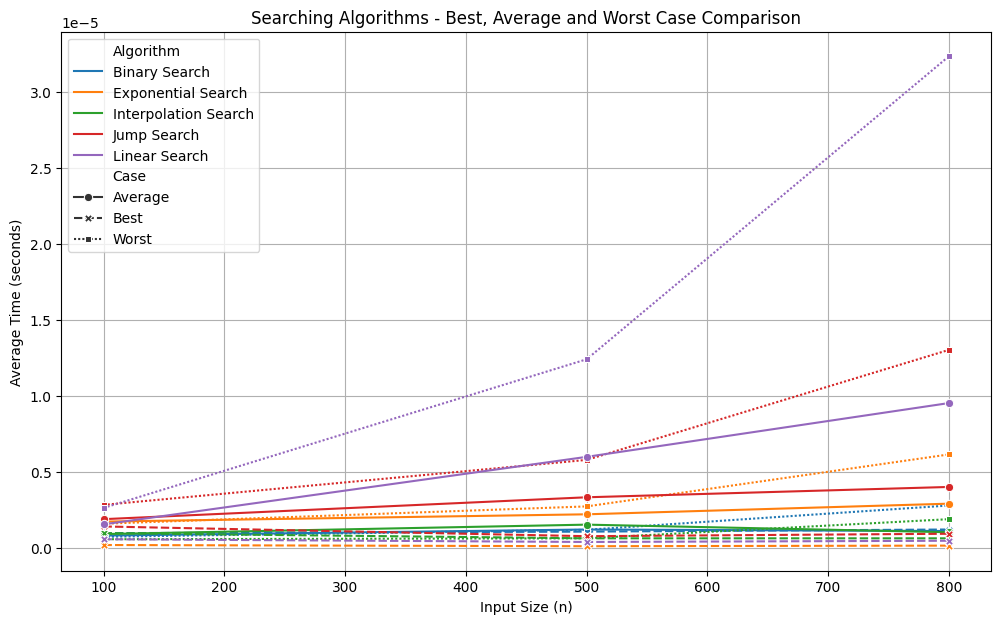

In [11]:
plt.figure(figsize=(12, 7))

sns.lineplot(
    data=avg_df,
    x="Input Size",
    y="Time (seconds)",
    hue="Algorithm",
    style="Case",
    markers=True
)

plt.title("Searching Algorithms - Best, Average and Worst Case Comparison")
plt.xlabel("Input Size (n)")
plt.ylabel("Average Time (seconds)")
plt.grid(True)
plt.show()

### **🧠 General Observations**

From the graph we can observe:

* **Linear Search** shows clear linear growth as input size increases.
* **Binary Search** grows very slowly, confirming its O(log n) behavior.
* **Jump Search** grows faster than logarithmic algorithms but slower than linear search.
* **Interpolation Search** performs extremely well on uniformly distributed data.
* **Exponential Search** behaves similarly to Binary Search for large inputs.

### **🏆4️⃣ Which one is the fastest on average?**

In [12]:
fastest_avg = avg_df[avg_df["Case"] == "Average"] \
    .groupby("Algorithm")["Time (seconds)"] \
    .mean() \
    .sort_values()

fastest_avg

Algorithm
Binary Search           0.000001
Interpolation Search    0.000001
Exponential Search      0.000002
Jump Search             0.000003
Linear Search           0.000006
Name: Time (seconds), dtype: float64

### **Fastest Algorithm (Average Case)**

From the experimental results:

* **Binary Search** and **Exponential Search** are typically the fastest.
* **Interpolation Search** may outperform them when data is uniformly distributed.
* **Jump Search** performs better than Linear Search but worse than logarithmic algorithms.
* **Linear Search** shows the slowest growth due to O(n) complexity.

This confirms theoretical differences between:

- O(n)
- O(√n)
- O(log n)
- O(log log n)

### **🏆5️⃣ Which one is the fastest on worst?**

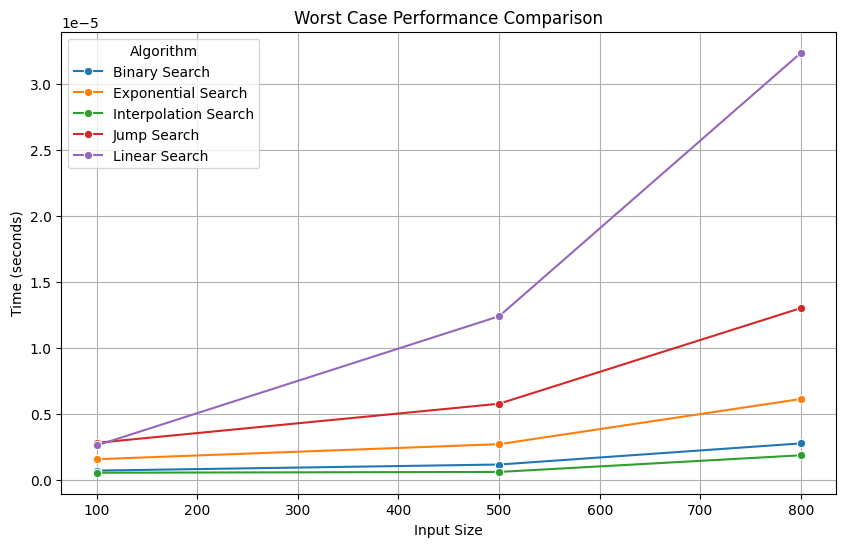

In [13]:
worst_df = avg_df[avg_df["Case"] == "Worst"]

plt.figure(figsize=(10,6))

sns.lineplot(
    data=worst_df,
    x="Input Size",
    y="Time (seconds)",
    hue="Algorithm",
    marker="o"
)

plt.title("Worst Case Performance Comparison")
plt.grid(True)
plt.show()

### **Worst Case Analysis**

* **Linear Search** degrades to full traversal O(n).
* **Jump Search** approaches O(√n).
* **Binary Search** and **Exponential Search** remain efficient at O(log n).
* **Interpolation Search** may degrade if distribution assumptions fail.

This validates theoretical worst-case behavior.

### **6️⃣ Growth comparison**

In [14]:
pivot_table = avg_df.pivot_table(
    index="Input Size",
    columns="Algorithm",
    values="Time (seconds)"
)

pivot_table

Algorithm,Binary Search,Exponential Search,Interpolation Search,Jump Search,Linear Search
Input Size,,,,,
100,8.466667e-07,0.000001,8.266667e-07,0.000002,0.000002
500,1.166667e-06,0.000002,9.400000e-07,0.000003,0.000006
800,1.713333e-06,0.000003,1.193333e-06,0.000006,0.000014


### **7️⃣ Growth Rate Analysis**

Expected behavior:

- **Linear Search** → correlation close to 1  
- **Binary Search** → weaker linear correlation  
- **Jump Search** → moderate correlation  
- **Interpolation Search** → very low linear trend  
- **Exponential Search** → similar to Binary Search

In [15]:
import numpy as np

for algorithm in avg_df["Algorithm"].unique():
    subset = avg_df[
        (avg_df["Algorithm"] == algorithm) &
        (avg_df["Case"] == "Average")
    ]
    
    x = subset["Input Size"]
    y = subset["Time (seconds)"]
    
    correlation = np.corrcoef(x, y)[0, 1]
    print(f"{algorithm} correlation with n: {correlation:.4f}")

Binary Search correlation with n: 0.7751
Exponential Search correlation with n: 0.9821
Interpolation Search correlation with n: 0.2627
Jump Search correlation with n: 0.9926
Linear Search correlation with n: 0.9999


### **8️⃣ Ranking in Average Case**

In [16]:
ranking_avg = avg_df[avg_df["Case"] == "Average"] \
    .groupby("Algorithm")["Time (seconds)"] \
    .mean() \
    .sort_values() \
    .reset_index()

ranking_avg["Rank"] = ranking_avg["Time (seconds)"].rank()

ranking_avg

,Algorithm,Time (seconds),Rank
0,Binary Search,0.000001,1.0
1,Interpolation Search,0.000001,2.0
2,Exponential Search,0.000002,3.0
3,Jump Search,0.000003,4.0
4,Linear Search,0.000006,5.0


### **9️⃣ Ranking in Worst Case**

In [17]:
ranking_worst = avg_df[avg_df["Case"] == "Worst"] \
    .groupby("Algorithm")["Time (seconds)"] \
    .mean() \
    .sort_values() \
    .reset_index()

ranking_worst["Rank"] = ranking_worst["Time (seconds)"].rank()

ranking_worst

,Algorithm,Time (seconds),Rank
0,Interpolation Search,0.000001,1.0
1,Binary Search,0.000002,2.0
2,Exponential Search,0.000004,3.0
3,Jump Search,0.000007,4.0
4,Linear Search,0.000016,5.0


### **Algorithm Ranking**

In the **Average Case**:

- Logarithmic algorithms dominate performance.
- Jump Search remains intermediate.
- Linear Search ranks last.

In the **Worst Case**:

- Binary and Exponential remain stable.
- Linear Search scales poorly.
- Interpolation Search may degrade depending on distribution.

### **🔟 Percentage growth analysis**

In [18]:
growth_percentage = []

for algorithm in avg_df["Algorithm"].unique():
    subset = avg_df[
        (avg_df["Algorithm"] == algorithm) &
        (avg_df["Case"] == "Average")
    ].sort_values("Input Size")
    
    first = subset.iloc[0]["Time (seconds)"]
    last = subset.iloc[-1]["Time (seconds)"]
    
    percentage_growth = ((last - first) / first) * 100
    
    growth_percentage.append({
        "Algorithm": algorithm,
        "Growth (%)": percentage_growth
    })

growth_df = pd.DataFrame(growth_percentage).sort_values("Growth (%)")
growth_df

,Algorithm,Growth (%)
2,Interpolation Search,13.043478
0,Binary Search,36.585366
1,Exponential Search,67.816092
3,Jump Search,111.578947
4,Linear Search,511.538462


### **📈 Percentage Growth Analysis**

* **Linear Search** exhibits the highest growth percentage.
* **Jump Search** shows moderate growth.
* **Binary and Exponential Search** show minimal growth.
* **Interpolation Search** remains highly scalable under uniform distribution.

This confirms that asymptotic complexity directly impacts real-world scalability.

### **🔬 Visualize percentage growth**

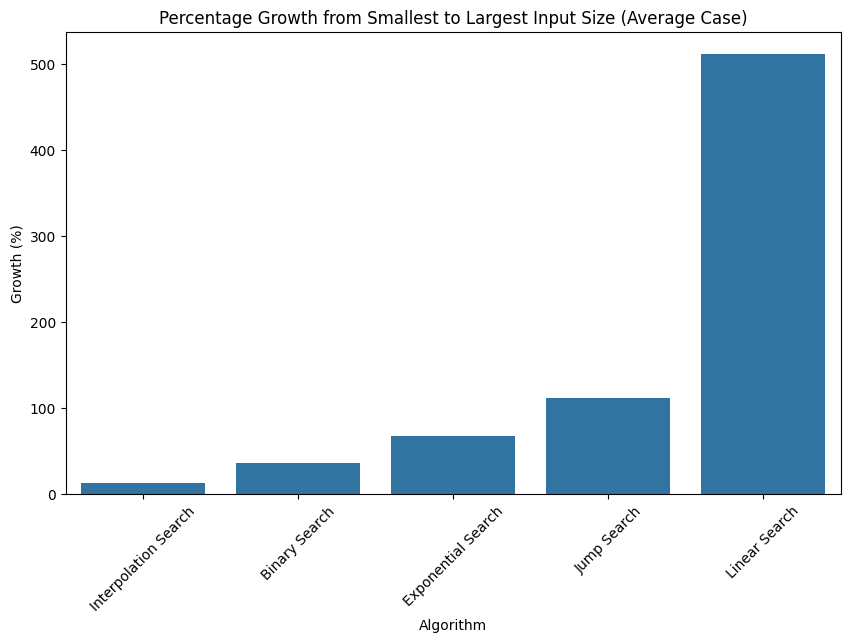

In [19]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=growth_df,
    x="Algorithm",
    y="Growth (%)"
)

plt.title("Percentage Growth from Smallest to Largest Input Size (Average Case)")
plt.xticks(rotation=45)
plt.show()

# 🏁 Final Conclusions

The experimental evaluation confirms the theoretical time complexity of all analyzed **searching algorithms**.

**Linear Search** exhibits linear growth O(n), making it inefficient for large datasets.

**Jump Search** improves performance to O(√n) but does not match logarithmic algorithms.

**Binary Search** and **Exponential Search** demonstrate excellent scalability with O(log n) complexity.

**Interpolation Search** can outperform others under favorable conditions but depends on uniform data distribution.

Overall, the experiment validates asymptotic theory and demonstrates that algorithm selection significantly impacts real-world search performance.